# 03 — Data Preprocessing

Build a reusable train/test pipeline: harmonise labels, impute, engineer a few features, encode, scale (**fit on train only**), and persist artefacts for baselines, GA, PSO, and TabNet.

In [1]:
from pathlib import Path
import random

import numpy as np

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

cwd = Path.cwd().resolve()
PROJECT_ROOT = next(
    (p for p in [cwd, *cwd.parents] if (p / "environment.yml").exists()),
    cwd,
)

DATA_RAW = PROJECT_ROOT / "data" / "raw"
DATA_INTERIM = PROJECT_ROOT / "data" / "interim"
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
REPORTS_DIR = PROJECT_ROOT / "reports"
MODELS_DIR = PROJECT_ROOT / "models"

for d in (DATA_INTERIM, DATA_PROCESSED, FIGURES_DIR, MODELS_DIR):
    d.mkdir(parents=True, exist_ok=True)

print(f"Project root : {PROJECT_ROOT}")
print(f"Random seed  : {RANDOM_SEED}")

Project root : C:\Users\ishan\OneDrive\Documents\Work\3 Year 2 Semester\IT41033 - Nature Inspired Algorithms\Mini Project\ecommerce-customer-churn-prediction
Random seed  : 42


In [2]:
import json
import joblib
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, RobustScaler, FunctionTransformer
from sklearn.base import BaseEstimator, TransformerMixin

df = pd.read_csv(DATA_INTERIM / "ecomm_validated.csv")
print(df.shape)

(5630, 20)


## Why these choices?

| Step | Choice | Justification |
|------|--------|----------------|
| Harmonise categories | Map Phone→Mobile Phone, CC→Credit Card, COD→Cash on Delivery, Mobile→Mobile Phone | EDA found overlapping labels that would create redundant one-hot columns |
| Impute | Median (numeric), most_frequent (categorical) | ~4–5% missingness; median resists skew |
| Ordinals | Keep CityTier, SatisfactionScore, Complain as integers | Preserve order; avoid exploding cardinality |
| Scale | RobustScaler on continuous numerics | Skew + IQR outliers from EDA |
| Split | Stratified 80/20, seed 42 | Preserve churn rate; reproducibility |

In [3]:
class FeatureEngineer(BaseEstimator, TransformerMixin):
    """Light domain features justified by EDA."""

    def fit(self, X, y=None):
        self.recency_threshold_ = float(X["DaySinceLastOrder"].median())
        return self

    def transform(self, X):
        X = X.copy()
        X["PreferredLoginDevice"] = X["PreferredLoginDevice"].replace({"Phone": "Mobile Phone"})
        X["PreferredPaymentMode"] = X["PreferredPaymentMode"].replace({
            "CC": "Credit Card", "COD": "Cash on Delivery",
        })
        X["PreferedOrderCat"] = X["PreferedOrderCat"].replace({"Mobile": "Mobile Phone"})

        tenure = X["Tenure"].fillna(X["Tenure"].median() if X["Tenure"].notna().any() else 0)
        X["TenureBin"] = pd.cut(
            tenure, bins=[-0.1, 3, 9, 15, 1e9],
            labels=[0, 1, 2, 3],
        ).astype(float)

        X["IsDormant"] = (X["DaySinceLastOrder"] > self.recency_threshold_).astype(float)
        X["UnhappyComplain"] = (
            (X["Complain"].fillna(0) == 1) & (X["SatisfactionScore"].fillna(3) <= 2)
        ).astype(float)
        return X


fe = FeatureEngineer()
df_fe = fe.fit_transform(df)
print("Recency threshold (global preview — train refit below):", fe.recency_threshold_)
df_fe[["TenureBin", "IsDormant", "UnhappyComplain"]].head()

Recency threshold (global preview — train refit below): 3.0


,TenureBin,IsDormant,UnhappyComplain
0,1.0,1.0,1.0
1,1.0,0.0,0.0
2,1.0,0.0,0.0
3,0.0,0.0,0.0
4,0.0,0.0,0.0


In [4]:
TARGET = "Churn"
ID_COL = "CustomerID"

y = df[TARGET].astype(int)
X = df.drop(columns=[TARGET])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_SEED, stratify=y,
)
print("Train", X_train.shape, "churn", y_train.mean())
print("Test ", X_test.shape, "churn", y_test.mean())

# Fit FE on train only
fe = FeatureEngineer()
X_train_fe = fe.fit_transform(X_train)
X_test_fe = fe.transform(X_test)

numeric_continuous = [
    "Tenure", "WarehouseToHome", "HourSpendOnApp", "NumberOfDeviceRegistered",
    "NumberOfAddress", "OrderAmountHikeFromlastYear", "CouponUsed", "OrderCount",
    "DaySinceLastOrder", "CashbackAmount",
]
ordinal_as_is = ["CityTier", "SatisfactionScore", "Complain", "TenureBin", "IsDormant", "UnhappyComplain"]
categorical = ["PreferredLoginDevice", "PreferredPaymentMode", "Gender", "PreferedOrderCat", "MaritalStatus"]

# Drop ID from modelling matrix
for part in (X_train_fe, X_test_fe):
    assert ID_COL in part.columns

preprocess = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", RobustScaler()),
        ]), numeric_continuous),
        ("ord", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
        ]), ordinal_as_is),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
        ]), categorical),
    ],
    remainder="drop",
)

X_train_model = X_train_fe.drop(columns=[ID_COL])
X_test_model = X_test_fe.drop(columns=[ID_COL])

X_train_p = preprocess.fit_transform(X_train_model)
X_test_p = preprocess.transform(X_test_model)

# Feature names
num_names = numeric_continuous
ord_names = ordinal_as_is
cat_names = list(preprocess.named_transformers_["cat"].named_steps["onehot"].get_feature_names_out(categorical))
feature_names = num_names + ord_names + cat_names
print("n_features:", len(feature_names))
print(feature_names[:15], "...")

Train (4504, 19) churn 0.16829484902309058
Test  (1126, 19) churn 0.16873889875666073
n_features: 33
['Tenure', 'WarehouseToHome', 'HourSpendOnApp', 'NumberOfDeviceRegistered', 'NumberOfAddress', 'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount', 'DaySinceLastOrder', 'CashbackAmount', 'CityTier', 'SatisfactionScore', 'Complain', 'TenureBin', 'IsDormant'] ...


## Visual checks (easy to understand)

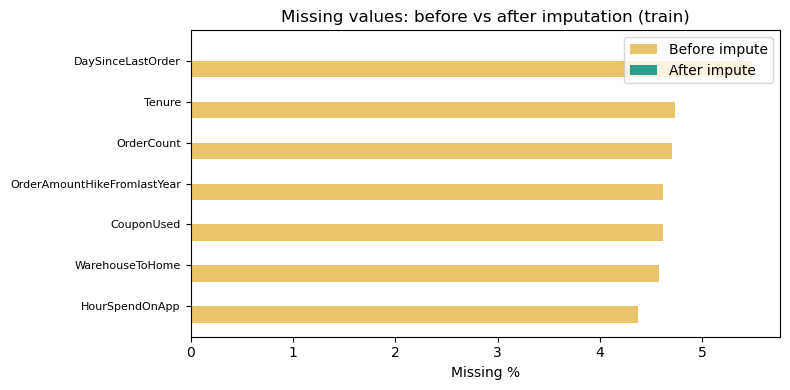

In [5]:
import matplotlib.pyplot as plt

# 1) Missing % before vs after (model matrix should be complete)
before_miss = (X_train_model[numeric_continuous + ordinal_as_is + categorical].isna().mean() * 100)
# After transform: dense array → no NaNs
after_miss = pd.Series(0.0, index=before_miss.index)

compare_miss = pd.DataFrame({"before_%": before_miss, "after_%": after_miss}).sort_values("before_%")
# Show only columns that had missingness OR top few
show = compare_miss.loc[compare_miss["before_%"] > 0]
if show.empty:
    show = compare_miss.tail(8)

fig, ax = plt.subplots(figsize=(8, 4))
y = range(len(show))
ax.barh([i - 0.2 for i in y], show["before_%"], height=0.4, label="Before impute", color="#e9c46a")
ax.barh([i + 0.2 for i in y], show["after_%"], height=0.4, label="After impute", color="#2a9d8f")
ax.set_yticks(list(y))
ax.set_yticklabels(show.index, fontsize=8)
ax.set_xlabel("Missing %")
ax.set_title("Missing values: before vs after imputation (train)")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / "03_missing_before_after.png", dpi=150)
plt.show()

**Insight (simple):** Yellow bars show gaps in the raw train data. Green bars should be ~0 after median/mode fill — the model never sees blank cells.

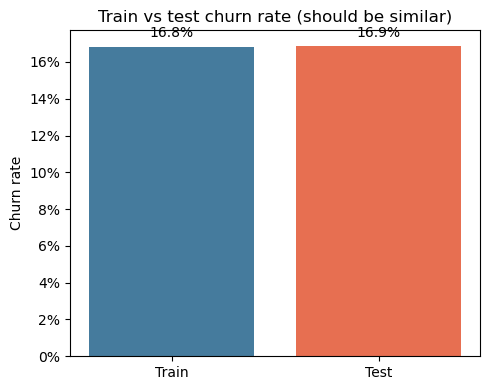

In [6]:
# 2) Train vs test churn rate (stratified split check)
fig, ax = plt.subplots(figsize=(5, 4))
rates = [float(y_train.mean()), float(y_test.mean())]
bars = ax.bar(["Train", "Test"], rates, color=["#457b9d", "#e76f51"])
ax.set_ylabel("Churn rate")
ax.set_title("Train vs test churn rate (should be similar)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
for b, r in zip(bars, rates):
    ax.text(b.get_x() + b.get_width() / 2, r + 0.005, f"{r:.1%}", ha="center")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "03_train_test_churn.png", dpi=150)
plt.show()

**Insight (simple):** Similar train/test churn % means the split kept class balance (stratify worked). That makes later metrics fair.

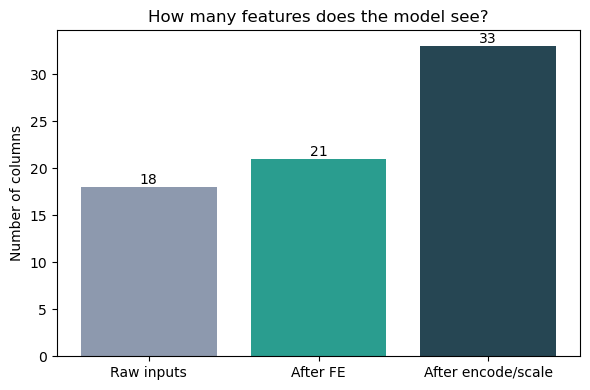

{'Raw inputs': 18, 'After FE': 21, 'After encode/scale': 33}


In [7]:
# 3) Feature count growth: raw -> engineered -> one-hot matrix
n_raw = X_train.drop(columns=[ID_COL]).shape[1]
n_fe = X_train_model.shape[1]
n_final = X_train_p.shape[1]
fig, ax = plt.subplots(figsize=(6, 4))
steps = ["Raw inputs", "After FE", "After encode/scale"]
vals = [n_raw, n_fe, n_final]
ax.bar(steps, vals, color=["#8d99ae", "#2a9d8f", "#264653"])
ax.set_ylabel("Number of columns")
ax.set_title("How many features does the model see?")
for i, v in enumerate(vals):
    ax.text(i, v + 0.3, str(v), ha="center")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "03_feature_count_steps.png", dpi=150)
plt.show()
print(dict(zip(steps, vals)))

**Insight (simple):** One-hot encoding expands categories into many 0/1 columns. That is normal — GA/PSO later try to **shrink** this set without losing F1.

In [8]:
bundle = {
    "feature_engineer": fe,
    "preprocessor": preprocess,
    "feature_names": feature_names,
    "numeric_continuous": numeric_continuous,
    "ordinal_as_is": ordinal_as_is,
    "categorical": categorical,
    "id_col": ID_COL,
    "random_seed": RANDOM_SEED,
}
joblib.dump(bundle, MODELS_DIR / "preprocessor.joblib")

# Persist matrices + IDs for later notebooks
pd.DataFrame(X_train_p, columns=feature_names).to_csv(DATA_PROCESSED / "X_train.csv", index=False)
pd.DataFrame(X_test_p, columns=feature_names).to_csv(DATA_PROCESSED / "X_test.csv", index=False)
y_train.to_csv(DATA_PROCESSED / "y_train.csv", index=False)
y_test.to_csv(DATA_PROCESSED / "y_test.csv", index=False)
X_train[[ID_COL]].to_csv(DATA_PROCESSED / "id_train.csv", index=False)
X_test[[ID_COL]].to_csv(DATA_PROCESSED / "id_test.csv", index=False)

meta = {
    "n_train": int(len(y_train)),
    "n_test": int(len(y_test)),
    "n_features": len(feature_names),
    "train_churn_rate": float(y_train.mean()),
    "test_churn_rate": float(y_test.mean()),
    "recency_threshold": float(fe.recency_threshold_),
}
(DATA_PROCESSED / "preprocess_meta.json").write_text(json.dumps(meta, indent=2), encoding="utf-8")
print(meta)

{'n_train': 4504, 'n_test': 1126, 'n_features': 33, 'train_churn_rate': 0.16829484902309058, 'test_churn_rate': 0.16873889875666073, 'recency_threshold': 3.0}


## Leakage checklist

- [x] Target `Churn` never used inside transformers
- [x] Imputer / scaler / one-hot / recency threshold fitted on **train only**
- [x] Stratified split before fitting
- [x] `CustomerID` excluded from model matrix
- [x] Test transform uses train statistics only
